# Generating Images from a pretrained flow matching model

This notebook generates an image using a pretrained flow matching model using the CIFAR10 dataset. In this notebook, we use Euler's method to simulate the ODE.

## Loading model checkpoints

Once a model is trained, a corresponding model checkpoint (eg. `checkpoint-99.pth`) is saved in `output_dir` along with the `args.json` that contains the command line arguments for the training run.

This notebook shows how to load a model checkpoint and generate a few snapshots.

In [35]:
from pathlib import Path
import json
from models.model_configs import instantiate_model
import torch
from training.eval_loop import CFGScaledModel
from training.edm_time_discretization import get_time_discretization
from flow_matching.path import MixtureDiscreteProbPath
from flow_matching.path.scheduler import PolynomialConvexScheduler
from flow_matching.solver.ode_solver import ODESolver
from flow_matching.solver.discrete_solver import MixtureDiscreteEulerSolver
from matplotlib import pyplot as plt

In [ ]:
# Substitute your pretrained checkpoint path
checkpoint_path = Path("inference/checkpoint.pth")
args_filepath = checkpoint_path.parent / 'args.json'
with open(args_filepath, 'r') as f:
    args_dict = json.load(f)

model = instantiate_model(architechture=args_dict['dataset'], is_discrete='discrete_flow_matching' in args_dict  and args_dict['discrete_flow_matching'],
                          use_ema=args_dict['use_ema'])
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
model.load_state_dict(checkpoint["model"])
model.train(False)

device = 'cuda'
model.to(device=device)

# Set the sampling resolution corresponding to the model
if 'train_blurred_64' in args_dict['data_path'] and args_dict['dataset'] == 'imagenet':
    sample_resolution = 64
elif 'train_blurred_32' in args_dict['data_path'] or args_dict['dataset'] == 'cifar10':
    sample_resolution = 32

batch_size = args_dict['batch_size']

# Generate from classes 1,2,..,batch_size - 1
labels = torch.tensor(list(range(batch_size)), dtype=torch.int32, device=device)
ode_opts = args_dict['ode_options']
ode_opts["method"] = args_dict['ode_method']

if args_dict['ode_method'] != 'euler':
    print("This notebook only implements for Euler's method ... changing ode_method to euler")
    args_dict['ode_method'] = 'euler'

# Wrap the model s.t. it does Classifier-Free Guidance.
cfg_weighted_model = CFGScaledModel(model=model)

model_extras = {'label': labels, 'cfg_scale': args_dict['cfg_scale']}
# the vector field function that takes in time t and the current position x
def ode_func(t, x):
    return cfg_weighted_model(x=x, t=t, **model_extras)

This notebook only implements for Euler's method ... changing ode_method to euler


## Simulating the ODE

Below, we simulate the ODE using Euler's method, with `cfg_weighted_model` as the velocity field. 

In [46]:
# define the step function
def euler_step(func, t0, x0, dt):
    # the step function for euler's method
    # given a vector field func, current time t0 and position x0,
    # the step is dt * func(t0, x0)
    f0 = func(t0, x0)
    return dt * f0
    
# Get the time discretization. 
if 'edm_schedule' in args_dict:
    time_grid = get_time_discretization(nfes=ode_opts["nfe"])
else:
    time_grid = torch.tensor([0.0, 1.0], device=device)

# sample x_0 from a gaussian distribution.
x_0 = torch.randn([batch_size, 3, sample_resolution, sample_resolution], dtype=torch.float32, device=device) 

# create a tensor for holding the intermediary position
solution = torch.empty(len(time_grid), *x_0.shape, dtype=x_0.dtype, device=x_0.device)
# store the initial value
solution[0] = x_0

# iterate over the time grid
j = 1
x0 = x_0
for t0, t1 in zip(time_grid[:-1], time_grid[1:]):
    # get the change in time
    dt = t1 - t0
    # get the change in position estimated by euler's step func
    dx = euler_step(ode_func, t0, x0, dt)
    # get the next position by updating
    # the current position with the change in position
    x1 = x0 + dx
    # store the intermediary position
    solution[j] = x1
    j += 1
    # update the current position
    x0 = x1

# we only care about the final position
synthetic_samples = solution[-1]

## Plotting the samples

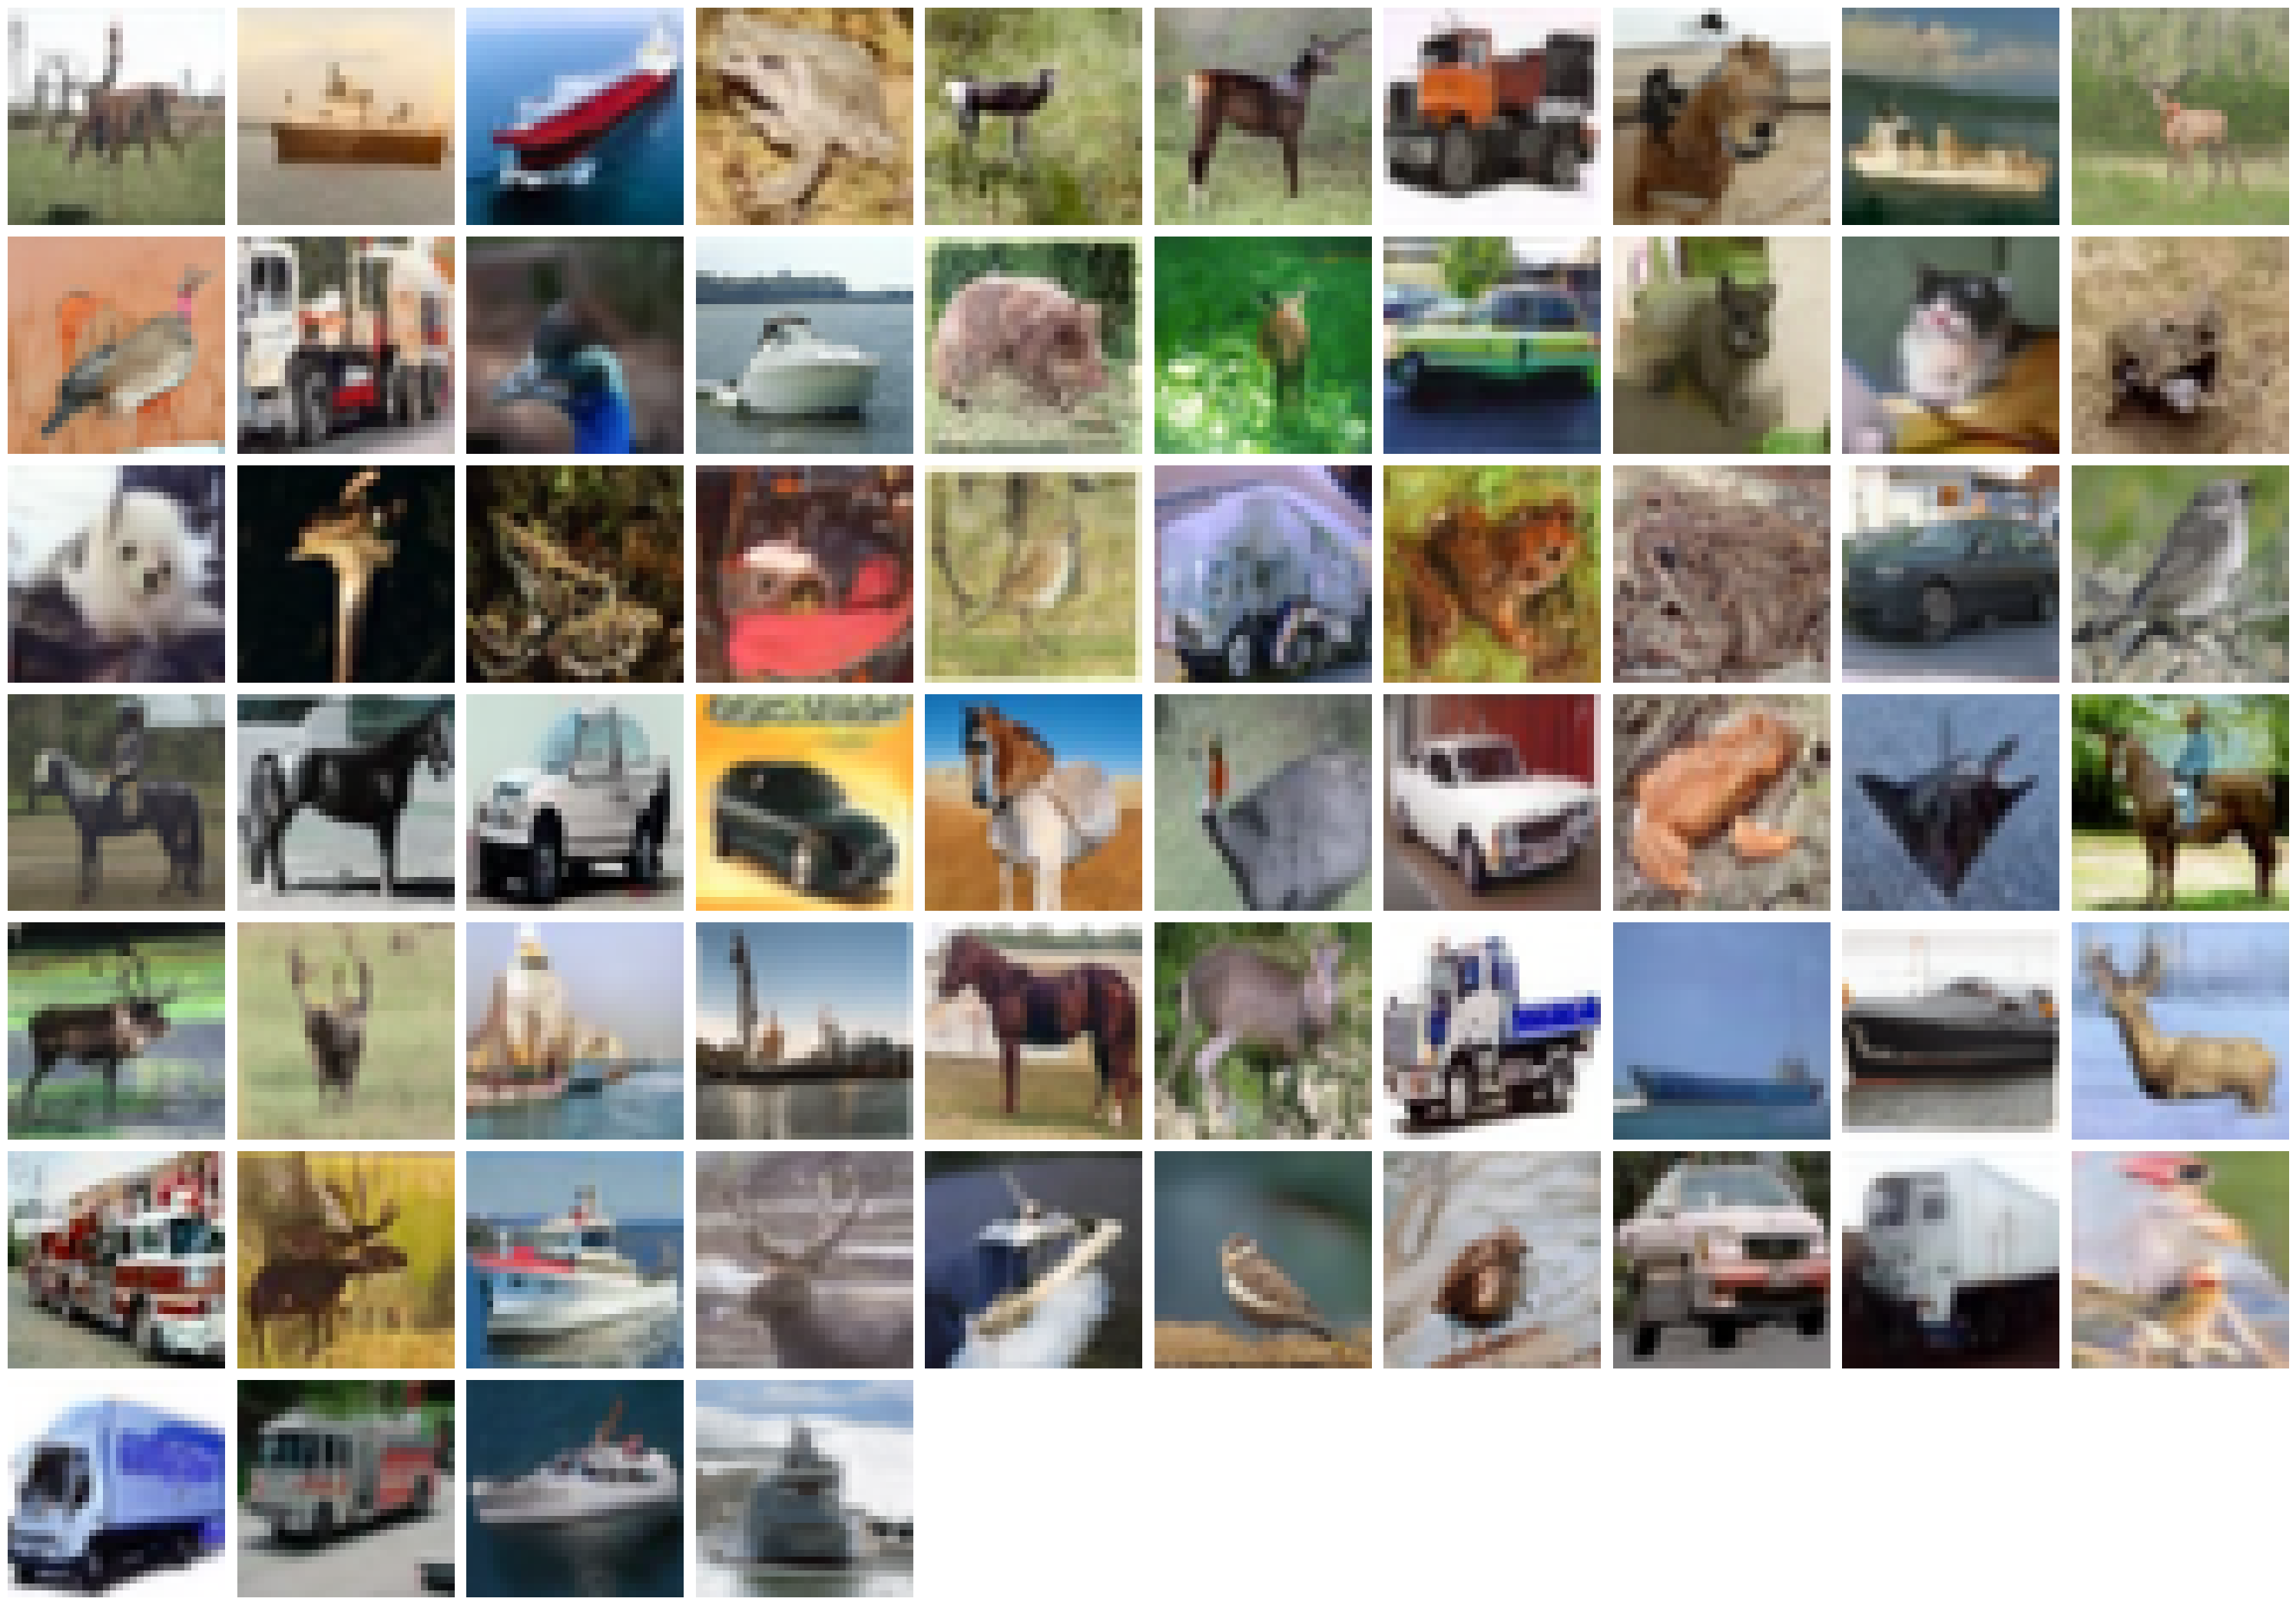

In [47]:
# Scaling to [0, 1] from [-1, 1]
synthetic_samples = torch.clamp(
    synthetic_samples * 0.5 + 0.5, min=0.0, max=1.0
)
synthetic_samples = torch.floor(synthetic_samples * 255) / 255.0
cols = 10
rows = (batch_size + cols - 1) // cols
plt.figure(figsize=(cols * 3, rows * 3))
for i in range(batch_size):
    image = synthetic_samples[i].cpu().permute(1, 2, 0).numpy()
    plt.subplot(rows, cols, i + 1)
    plt.imshow(image)
    plt.axis('off')
plt.tight_layout()
plt.show()